<h1 align="center">Task 2 — Model Development Using Logistic Regression</h1>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Data ingestion only 2nd sheet in Excel . So mention that sheet name here .
df=pd.read_excel(r"C:\Users\ELCOT\Desktop\JananiMurugan\Machine_Learning\Dataset\ML_data1.xlsx",sheet_name="Model_Dev")
df

,Student_ID,Department,Attendance,Study_Hours,Assignment_Score,Internal_Marks,Previous_GPA,Backlogs,Library_Hours,Final_Score,Pass_Fail
0,1001,CSE,92,8.0,88,82,8.6,0,6,87,Pass
1,1002,IT,76,5.0,72,68,7.2,1,3,71,Pass
2,1003,ECE,61,3.5,55,52,6.4,3,1,54,Fail
3,1004,AI&DS,95,9.0,94,91,9.1,0,8,93,Pass
4,1005,BBA,68,4.0,61,58,6.8,2,2,60,Pass


### DATA QUALITY CHECK

In [3]:
# to find null values
df.isnull().sum()

Student_ID          0
Department          0
Attendance          0
Study_Hours         0
Assignment_Score    0
Internal_Marks      0
Previous_GPA        0
Backlogs            0
Library_Hours       0
Final_Score         0
Pass_Fail           0
dtype: int64

In [4]:
# to find duplicates
df.duplicated().sum()

np.int64(0)

### FEATURE AND TARGET SELECTION

In [10]:
#  Extracting features without drop
# So  the following is  called as feature selection

X = df[
    ["Attendance",
    "Study_Hours",
    "Assignment_Score",
    "Internal_Marks",
    "Previous_GPA",
    "Backlogs",
    "Library_Hours"
    ]
]

# Select Target
y=df["Pass_Fail"]

In [11]:
# This will show how many Pass and Fail values you have.
y=df["Pass_Fail"]
y.value_counts()

Pass_Fail
Pass    4
Fail    1
Name: count, dtype: int64

In [12]:
# To view the selected features and target
pd.concat([X,y],axis=1)

,Attendance,Study_Hours,Assignment_Score,Internal_Marks,Previous_GPA,Backlogs,Library_Hours,Pass_Fail
0,92,8.0,88,82,8.6,0,6,Pass
1,76,5.0,72,68,7.2,1,3,Pass
2,61,3.5,55,52,6.4,3,1,Fail
3,95,9.0,94,91,9.1,0,8,Pass
4,68,4.0,61,58,6.8,2,2,Pass


### LABEL_ENCODING

In [7]:
encoder = LabelEncoder()

In [8]:
df["Pass_Fail_encoded"]=encoder.fit_transform(df["Pass_Fail"])
df["Pass_Fail_encoded"]

0    1
1    1
2    0
3    1
4    1
Name: Pass_Fail_encoded, dtype: int64

## Train-Test Split
Split the data into training and testing sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split (
    X,y,
    test_size = 0.2,
    random_state = 42
)

In [14]:
# To view the shape of train and test sets

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# X_train (4, 7) → 4 rows × 7 features
# X_test (1, 7) → 1 row × 7 features
# y_train (4,) → 4 Pass values
# y_test (1,) → 1 Fail value

X_train: (4, 7)
X_test: (1, 7)
y_train: (4,)
y_test: (1,)


### SCALING
##### Using Standard_Scaler

In [15]:
num_cols = [
    "Attendance",
    "Study_Hours",
    "Assignment_Score",
    "Internal_Marks",
    "Previous_GPA",
    "Backlogs",
    "Library_Hours"
]

std_scaler = StandardScaler()

X_train[num_cols] = std_scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = std_scaler.transform(X_test[num_cols])

In [13]:
# To print both train and test set
print("X_train:")
print(X_train[num_cols].head())

print("\nX_test:")
print(X_test[num_cols].head())

X_train:
   Attendance  Study_Hours  Assignment_Score  Internal_Marks  Previous_GPA  \
4   -0.745870    -0.882596         -0.804984       -0.786666     -0.806064   
2   -1.220514    -1.090266         -1.162755       -1.156862     -1.154632   
0    0.881483     0.778761          0.804984        0.694117      0.762493   
3    1.084902     1.194101          1.162755        1.249411      1.198203   

   Backlogs  Library_Hours  
4  0.577350      -0.786334  
2  1.347151      -1.135815  
0 -0.962250       0.611593  
3 -0.962250       1.310556  

X_test:
   Attendance  Study_Hours  Assignment_Score  Internal_Marks  Previous_GPA  \
1   -0.203419    -0.467257         -0.149071       -0.169673     -0.457496   

   Backlogs  Library_Hours  
1  -0.19245      -0.436852  


## Build Logistic Regression Model
##### (i) Model_Building & Training

In [16]:
log_model = LogisticRegression()

# Trains the model using:

# X_train → input/features (attendance, study hours, marks, etc.)
# y_train → actual Final_Score


# .fit() = teach the model using training data

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

### (ii). Model Prediction
##### For testing model

In [17]:
y_pred=log_model.predict(X_test)
y_pred

array(['Pass'], dtype=object)

In [16]:
# To cross compare the values
print("Actual: " ,y_test.values)
print("Predict: " , y_pred)

Actual:  <StringArray>
['Pass']
Length: 1, dtype: str
Predict:  ['Pass']


##### For training model

In [ ]:
# y_pred=log_model.predict(X_train)
# y_pred

array(['Pass', 'Fail', 'Pass', 'Pass'], dtype=object)

In [ ]:
# To cross compare the values
# print("Actual: " ,y_train.values)
# print("Predict: " , y_pred)

Actual:  <StringArray>
['Pass', 'Fail', 'Pass', 'Pass']
Length: 4, dtype: str
Predict:  ['Pass' 'Fail' 'Pass' 'Pass']


### (i). Accuracy Score Metrics

In [18]:
# Overall correct prediction is known as accuracy
# It is a classification metrics

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


### (ii). Confusion Matrix

In [23]:
# This matrix is used in classification because  (pass or fail)
# Here it doesn't shown properly. Because I have 1 test case,So leave this matrix
Conf_matrix = confusion_matrix(y_test, y_pred,labels=["Fail", "Pass"])
print("Conf_matrix:" ,Conf_matrix)

Conf_matrix: [[0 0]
 [0 1]]


### (iii). Classification_report Matirx

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Pass       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



### Compare Actual vs Predicted

In [19]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results)

  Actual Predicted
1   Pass      Pass


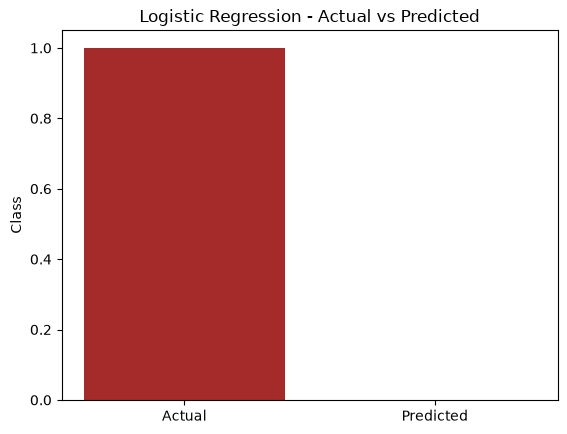

In [22]:
import matplotlib.pyplot as plt

plt.bar(["Actual", "Predicted"], [1,0],color="Brown")

plt.title("Logistic Regression - Actual vs Predicted")
plt.ylabel("Class")
plt.show()

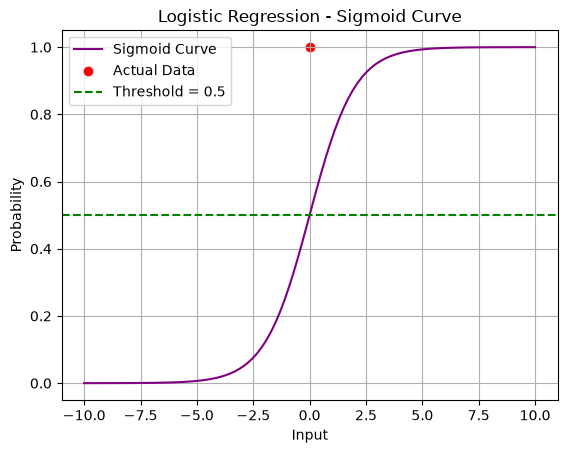

In [33]:

# Convert Pass/Fail to 0/1 for plotting
y_actual = np.where(y_test == "Pass", 1, 0)

# Create x values for sigmoid curve
x = np.linspace(-10, 10, 100)

# Sigmoid function
y = 1 / (1 + np.exp(-x))

# Sigmoid curve
plt.plot(x, y, label="Sigmoid Curve",color="Purple")

# Actual data points
plt.scatter(range(len(y_actual)), y_actual, label="Actual Data",color="Red")

# Classification threshold
plt.axhline(0.5, linestyle="--", label="Threshold = 0.5",color="Green")

plt.title("Logistic Regression - Sigmoid Curve")
plt.xlabel("Input")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)

plt.show()